In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [3]:
import pandas as pd
df = pd.read_csv("/content/Wholesale customers data.csv")

print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [4]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [5]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [8]:
from sklearn.preprocessing import StandardScaler

X = df[
    [
        'Fresh',
        'Milk',
        'Grocery',
        'Frozen',
        'Detergents_Paper',
        'Delicassen'
    ]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.cluster import DBSCAN

X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(
    eps=0.3,
    min_samples=4
)

In [12]:
clusters = dbscan.fit_predict(X_scaled)

In [14]:
df["Cluster"] = clusters

print("\nCluster Summary")
print(df["Cluster"].value_counts())

for i in sorted(df["Cluster"].unique()):

    print("\n" + "="*50)

    if i == -1:
        print("NOISE POINTS")
    else:
        print("CLUSTER", i + 1)

    print("="*50)

    cluster_data = df[
        df["Cluster"] == i
    ]

    print(
        cluster_data[
            [
                "Fresh",
                "Milk",
                "Grocery",
                "Frozen",
                "Detergents_Paper",
                "Delicassen"
            ]
        ]
    )

    print(
        "\nTotal Records :",
        len(cluster_data)
    )


Cluster Summary
Cluster
-1    314
 0    109
 1     17
Name: count, dtype: int64

NOISE POINTS
     Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0    12669   9656     7561     214              2674        1338
1     7057   9810     9568    1762              3293        1776
2     6353   8808     7684    2405              3516        7844
3    13265   1196     4221    6404               507        1788
4    22615   5410     7198    3915              1777        5185
..     ...    ...      ...     ...               ...         ...
434  16731   3922     7994     688              2371         838
435  29703  12051    16027   13135               182        2204
436  39228   1431      764    4510                93        2346
437  14531  15488    30243     437             14841        1867
438  10290   1981     2232    1038               168        2125

[314 rows x 6 columns]

Total Records : 314

CLUSTER 1
     Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
11   

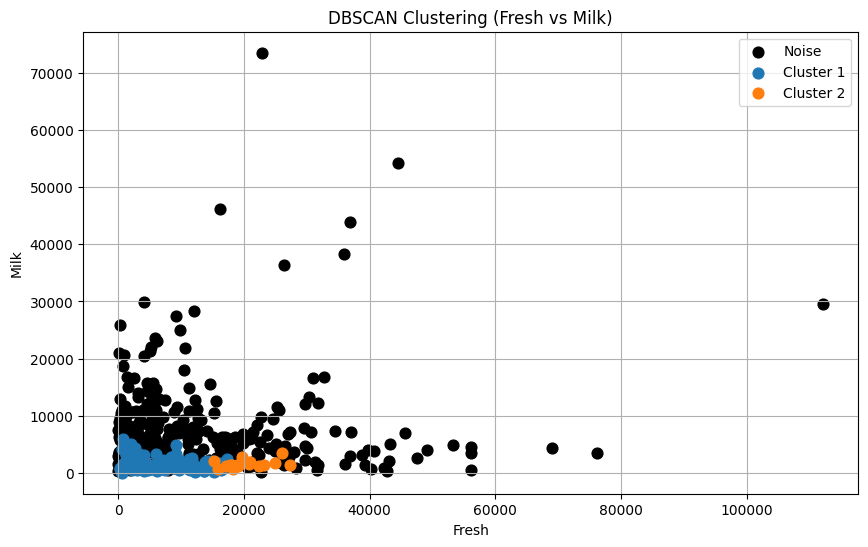

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for cluster in sorted(df["Cluster"].unique()):

    cluster_data = df[
        df["Cluster"] == cluster
    ]

    if cluster == -1:

        plt.scatter(
            cluster_data["Fresh"],
            cluster_data["Milk"],
            color="black",
            label="Noise",
            s=60
        )

    else:

        plt.scatter(
            cluster_data["Fresh"],
            cluster_data["Milk"],
            label=f"Cluster {cluster+1}",
            s=60
        )

plt.xlabel("Fresh")
plt.ylabel("Milk")

plt.title("DBSCAN Clustering (Fresh vs Milk)")

plt.legend()
plt.grid(True)

plt.show()